In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

sns.set_style("whitegrid")

In [3]:
RESULTS_DIR = Path("../results")

FILES = [
    RESULTS_DIR / "logreg.pkl",
    RESULTS_DIR / "rf.pkl",
    RESULTS_DIR / "gru.pkl",
]

models = []
for f in FILES:
    with open(f, "rb") as fh:
        models.append(pickle.load(fh))

# sanity check
for m in models:
    print(f'{m["name"]:>20s} | acc={m["acc"]:.4f} | N={len(m["y_true"])}')

 Logistic Regression | acc=0.5110 | N=19908
       Random Forest | acc=0.5333 | N=23838
                 GRU | acc=0.5188 | N=780892


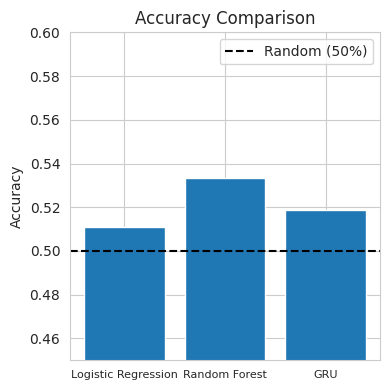

In [ ]:
plt.figure(figsize=(4,4))

plt.bar(
    [m["name"] for m in models],
    [m["acc"] for m in models],
)
plt.xticks(fontsize=7)

plt.axhline(0.5, color="k", linestyle="--", label="Random (50%)")
plt.ylim(0.45, 0.6)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()

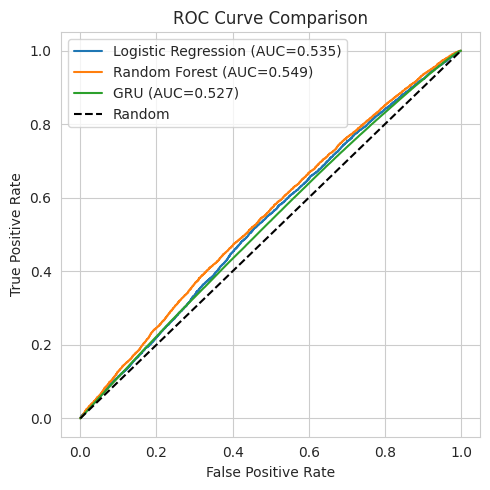

In [5]:
plt.figure(figsize=(5,5))

for m in models:
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_prob"])
    auc = roc_auc_score(m["y_true"], m["y_prob"])
    plt.plot(fpr, tpr, label=f'{m["name"]} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.show()

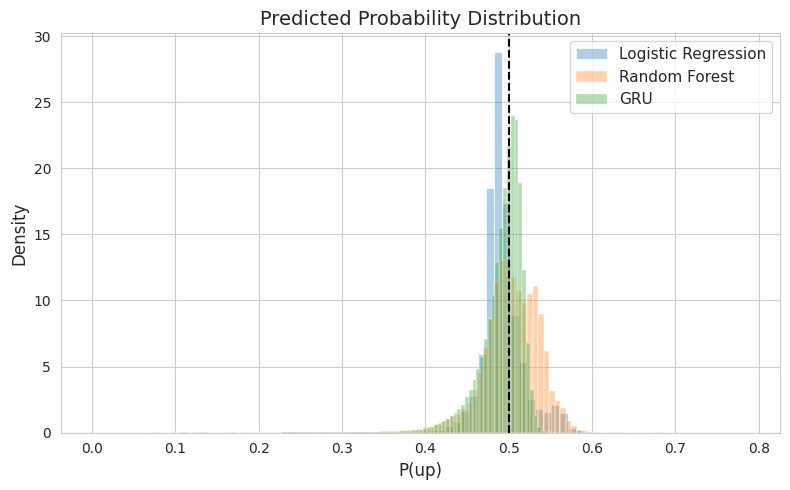

In [ ]:
plt.figure(figsize=(8,5))

for m in models:
    sns.histplot(
        m["y_prob"],
        bins=80,
        stat="density",
        fill=True,
        alpha=0.35,
        label=m["name"],
    )

plt.axvline(0.5, color="k", linestyle="--", linewidth=1.5)
plt.xlabel("P(up)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Predicted Probability Distribution", fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

summary = pd.DataFrame({
    "Model": [m["name"] for m in models],
    "Accuracy": [m["acc"] for m in models],
    "ROC–AUC": [roc_auc_score(m["y_true"], m["y_prob"]) for m in models],
})

summary.sort_values("ROC–AUC", ascending=False)

,Model,Accuracy,ROC–AUC
1,Random Forest,0.533308,0.549138
0,Logistic Regression,0.510950,0.534575
2,GRU,0.518835,0.527042


In [9]:
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# Accuracy
plt.figure(figsize=(5,3))
plt.bar(summary["Model"], summary["Accuracy"])
plt.axhline(0.5, linestyle="--", color="k")
plt.ylim(0.45,0.6)
plt.title("Accuracy Comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_comparison.png", dpi=300)
plt.close()

# ROC
plt.figure(figsize=(5,5))
for m in models:
    fpr,tpr,_ = roc_curve(m["y_true"], m["y_prob"])
    auc = roc_auc_score(m["y_true"], m["y_prob"])
    plt.plot(fpr,tpr,label=f'{m["name"]} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_comparison.png", dpi=300)
plt.close()
